# Assignment 5: Generative Models


## Problem 5.1: Variational Autoencoder

### Variational Autoencoder (VAE) on Fashion-MNIST

This notebook implements a Variational Autoencoder (VAE) using PyTorch.

Objectives:
- Train a VAE on Fashion-MNIST.
- Implement the reparameterization trick.
- Visualize latent representations using t-SNE.
- Generate new images by sampling from the latent space.
- Perform latent space interpolation between images.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.manifold import TSNE

### Load Fashion-MNIST Dataset

Fashion-MNIST contains 70,000 grayscale clothing images of size 28×28.

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:11<00:00, 2.34MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 291kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 2.35MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 6.98MB/s]


Training samples: 60000
Testing samples: 10000


### Visualize Sample Images

Display sample Fashion-MNIST images from different clothing categories.

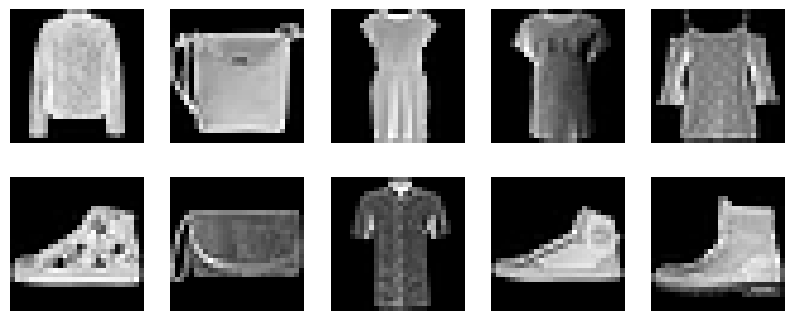

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

### Define Variational Autoencoder Architecture

The VAE consists of:
- Encoder
- Latent Space
- Decoder

The encoder compresses images into a latent representation and the decoder reconstructs images.

In [5]:
class VAE(nn.Module):
    
    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

### Complete Variational Autoencoder

The encoder produces the latent mean and variance.

The reparameterization trick samples latent vectors.

The decoder reconstructs images from latent representations.

In [6]:
class VAE(nn.Module):

    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):

        h = torch.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        h = torch.relu(self.fc3(z))

        return torch.sigmoid(self.fc4(h))

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [7]:
model = VAE(latent_dim=2)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


### Define VAE Loss Function

The VAE loss consists of:

1. Reconstruction Loss
   Measures how well the reconstructed image matches the original image.

2. KL Divergence Loss
   Forces the latent distribution to remain close to a standard normal distribution.

Total Loss = Reconstruction Loss + KL Divergence

In [8]:
def vae_loss(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss

### Initialize VAE and Optimizer

Create the VAE model and Adam optimizer.

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = VAE(latent_dim=2).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(device)

cpu


### Train Variational Autoencoder

The model learns to:

- compress images into latent space
- reconstruct images
- maintain a smooth latent distribution

In [11]:
epochs = 10

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for images, _ in train_loader:

        images = images.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(images)

        loss = vae_loss(
            recon,
            images,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {train_loss/len(train_loader.dataset):.4f}"
    )

Epoch 1, Loss: 290.9097
Epoch 2, Loss: 272.0376
Epoch 3, Loss: 269.2120
Epoch 4, Loss: 267.5568
Epoch 5, Loss: 266.4566
Epoch 6, Loss: 265.5884
Epoch 7, Loss: 264.9596
Epoch 8, Loss: 264.3968
Epoch 9, Loss: 263.9501
Epoch 10, Loss: 263.6260


### Visualize Image Reconstructions

Compare original Fashion-MNIST images with their reconstructed versions produced by the VAE.

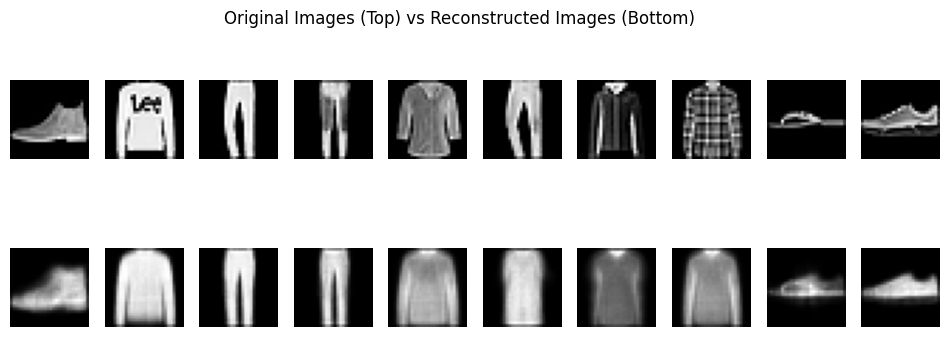

In [12]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images[:10].to(device)

    flat_images = images.view(-1, 784)

    recon, _, _ = model(flat_images)

    recon = recon.view(-1, 1, 28, 28)

plt.figure(figsize=(12,4))

for i in range(10):

    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(recon[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original Images (Top) vs Reconstructed Images (Bottom)")
plt.show()

### Extract Latent Representations

Encode test images into the latent space and collect latent vectors for visualization.

In [13]:
model.eval()

latent_vectors = []
labels_list = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(-1,784).to(device)

        mu, logvar = model.encode(images)

        latent_vectors.append(mu.cpu().numpy())
        labels_list.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors)
labels_list = np.concatenate(labels_list)

print(latent_vectors.shape)

(10000, 2)


### Visualize Latent Space Using t-SNE

t-SNE projects latent representations into a 2D space to visualize how different clothing categories cluster together.

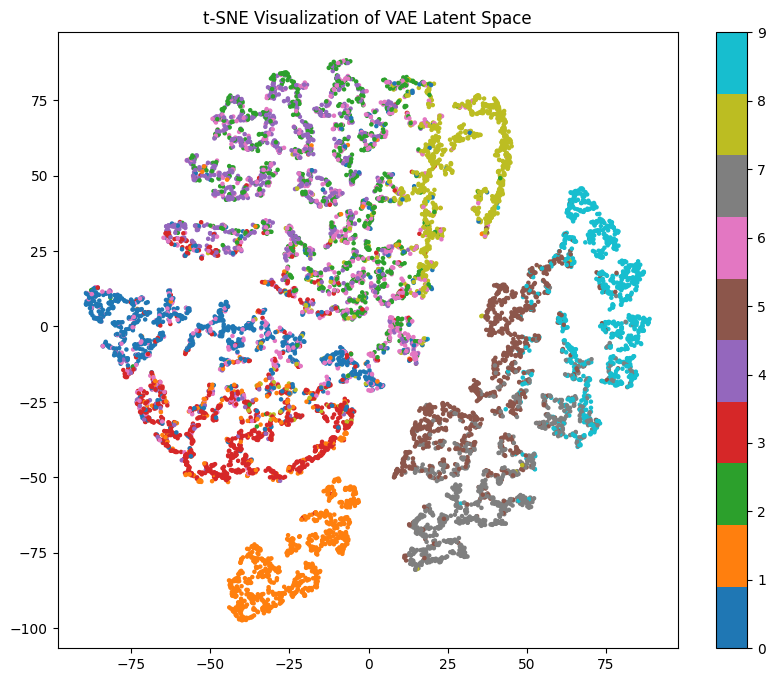

In [14]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

latent_tsne = tsne.fit_transform(
    latent_vectors
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    latent_tsne[:,0],
    latent_tsne[:,1],
    c=labels_list,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)

plt.title("t-SNE Visualization of VAE Latent Space")

plt.show()

### Generate New Samples

Sample random points from the latent space and generate completely new Fashion-MNIST images using the decoder.

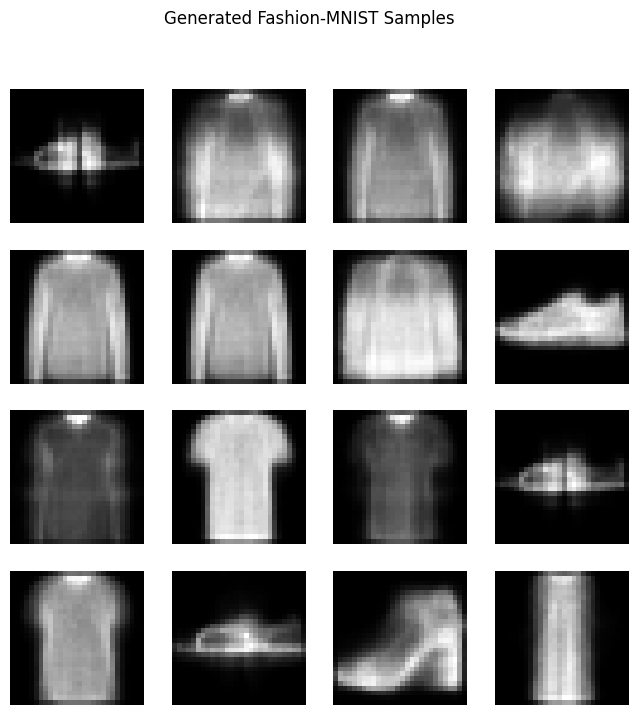

In [15]:
model.eval()

with torch.no_grad():

    z = torch.randn(16, 2).to(device)

    generated = model.decode(z)

    generated = generated.view(-1, 28, 28)

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated[i].cpu(),
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle("Generated Fashion-MNIST Samples")

plt.show()

### Latent Space Interpolation

Interpolate between two images in latent space and observe how one object gradually transforms into another.

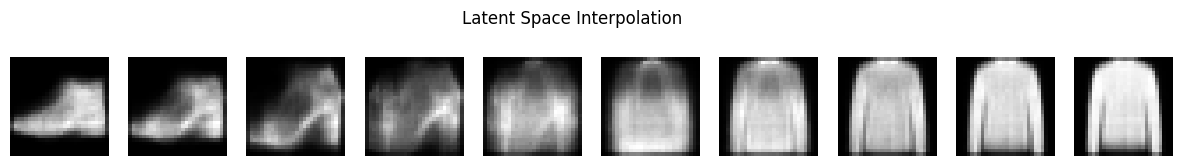

In [16]:
model.eval()

with torch.no_grad():

    # Select two test images
    img1 = test_dataset[0][0].view(1,784).to(device)
    img2 = test_dataset[1][0].view(1,784).to(device)

    # Encode
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    # Interpolate
    steps = 10

    interpolated_images = []

    for alpha in np.linspace(0,1,steps):

        z = (1-alpha)*mu1 + alpha*mu2

        recon = model.decode(z)

        interpolated_images.append(
            recon.view(28,28).cpu().numpy()
        )

plt.figure(figsize=(15,2))

for i,img in enumerate(interpolated_images):

    plt.subplot(1,steps,i+1)

    plt.imshow(img,cmap='gray')

    plt.axis('off')

plt.suptitle("Latent Space Interpolation")

plt.show()

## Final Analysis

The Variational Autoencoder successfully learned a compressed latent representation of Fashion-MNIST images.

The reconstruction results show that the model preserved the overall structure of clothing items while reducing image details due to the low-dimensional latent space.

The t-SNE visualization demonstrated meaningful clustering of clothing categories, indicating that semantically similar items were grouped together in latent space.

New samples generated from random latent vectors resembled realistic Fashion-MNIST images, confirming that the decoder learned the underlying data distribution.

Latent space interpolation produced smooth transitions between different clothing categories, demonstrating that the learned latent space was continuous and well-structured.